# Test Cases from Hart 2003
In this notebook, we compute CPS parameters for the cyclones that have been included in Hart (2003).

In [42]:
import huracanpy
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from cpys import compute_cps_parameters, plot_cps

# Vertical levels for the snapshots in the snaps/ folder, in Pa
snaps_levels = np.array([   1,    2,    3,    5,    7,   10,   20,   30,   50,   70,  100,  125,
        150,  175,  200,  225,  250,  300,  350,  400,  450,  500,  550,  600,
        650,  700,  750,  775,  800,  825,  850,  875,  900,  925,  950,  975,
       1000])*100

### Floyd 1999
Link to Hart's images : https://moe.met.fsu.edu/cyclonephase/archive/1999/

INFO:cpys:Computing B...
INFO:cpys:Level 90000 is taken for 900hPa
Level 60000 is taken for 600hPa

INFO:cpys:Computing VTL & VTU...


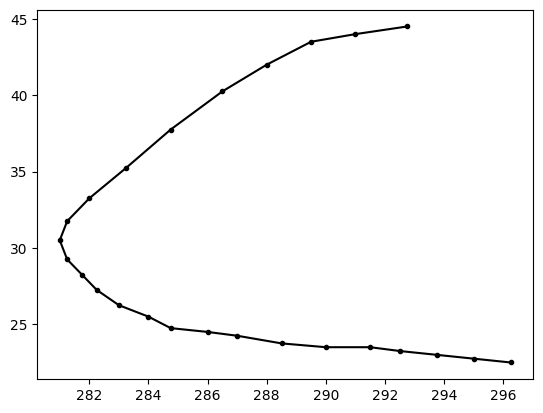

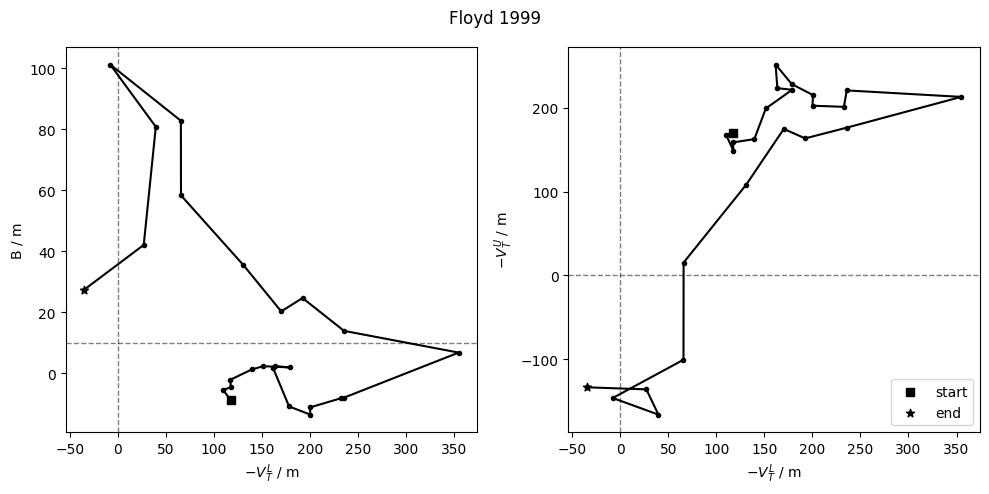

In [139]:
track = huracanpy.load("tracks/Floyd_1999.csv") # Open the track data
track = track.where(track.time >= np.datetime64("1999-09-12"), drop = True) # In Hart 2003, the track starts in Sept. 12th
plt.plot(track.lon, track.lat, color = "k", marker = ".")

snaps = xr.open_dataset("snaps/Floyd_1999.nc").assign(level = snaps_levels) # Open the snapshots along the track
snaps = snaps.where(snaps.snap_time >= np.datetime64("1999-09-12"), drop = True) # In Hart 2003, the track starts in Sept. 12th
snaps["snap_geopt"] /= 9.81 # Convert geopotential to m

# Compute the Hart CPS parameters
track_w_cps = compute_cps_parameters(track, snaps.snap_geopt)
# Visualise
plot_cps(track_w_cps, "Floyd 1999")

Right: 3399.495072705079 
Left: 3413.057124169921 
B -> -13.562051464841716


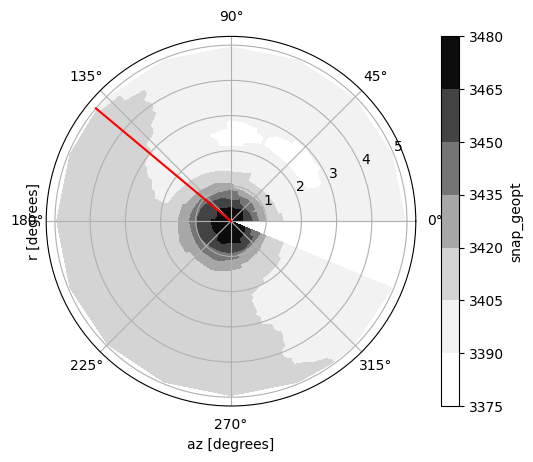

In [144]:
# Reproduce figure from 2003 paper
t = track_w_cps.where(track_w_cps.time == np.datetime64('1999-09-14T12:00:00.000000000'), drop = True)
z = snaps.snap_geopt.where(snaps.snap_time == np.datetime64('1999-09-14T12:00:00.000000000'), drop = True)
z["az"] = z.az * np.pi / 180 # Convert azimuth to degrees
z900 = z.sel(level = 900e2)
z600 = z.sel(level = 600e2)
ax = plt.axes(projection = "polar")
(z600 - z900).squeeze().plot.contourf(ax =ax, cmap = "Greys")
ax.plot([t.theta*np.pi/180]*2, [0,5], color = "r")

from cpys._hart import right_left
dz = z600 - z900
dz["az"] = dz.az * 180 / np.pi
dz_r, dz_l = right_left(dz, t.theta)
print("Right:",dz_r.weighted(dz.r).mean(["az", "r"]).values[0], 
    "\nLeft:", dz_l.weighted(dz.r).mean(["az", "r"]).values[0], 
    "\nB ->", t.B.values[0])

VTL: 200.55542355701414 
VTU: 215.17871838178795


array([200.55542356])

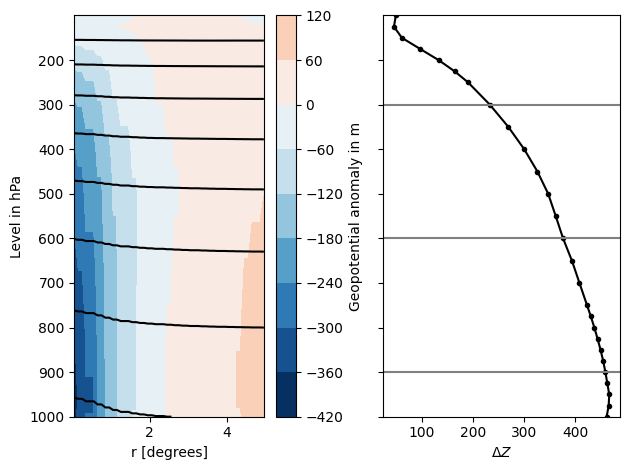

In [151]:
fig, axs = plt.subplots(1, 2, sharey = True)
z.sel(az = 0).squeeze().plot.contour(colors = "k", levels = np.arange(0, 15001, 2000), ax = axs[0])
c = (z.sel(az = 0) - z.weighted(z.r).mean(["az", "r"])).squeeze().plot.contourf(ax = axs[0], add_colorbar = False)
plt.colorbar(c, label = "Geopotential anomaly in m")
axs[0].set_title("")

deltaZ = (z.max(["r", "az"]) - z.min(["r", "az"])).squeeze()
axs[1].plot(deltaZ, deltaZ.level, color = 'k', marker = ".")
axs[1].axhline(y = 900e2, color = "grey")
axs[1].axhline(y = 600e2, color = "grey")
axs[1].axhline(y = 300e2, color = "grey")
axs[1].set_xlabel(r'$\Delta Z$')

plt.ylim(1000e2, 100e2)
axs[0].set_yticks(np.arange(1000e2, 100e2, -100e2), np.arange(1000, 100, -100))
axs[0].set_ylabel("Level in hPa")
plt.tight_layout()

print("VTL:", t.VTL.values[0], 
    "\nVTU:", t.VTU.values[0], )
from cpys import vt
vt(z.rename({"level":"plev"}), p_bottom = 950e2, p_top = 600e2)

### Mitch 1998
https://moe.met.fsu.edu/cyclonephase/archive/1998/

INFO:cpys:Computing B...
INFO:cpys:Level 90000 is taken for 900hPa
Level 60000 is taken for 600hPa

INFO:cpys:Computing VTL & VTU...


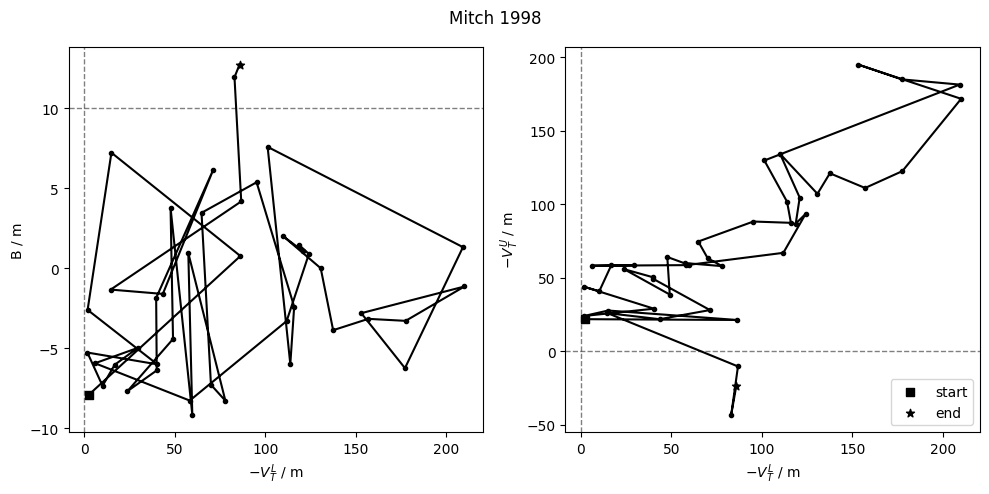

In [156]:
track = huracanpy.load("tracks/Mitch_1998.csv") # Open the track data
track = track.where(track.time <= np.datetime64("1998-11-04"), drop = True) # In Hart 2003, the track ends on Nov. 4th
snaps = xr.open_dataset("snaps/Mitch_1998.nc").assign(level = snaps_levels) # Open the snapshots along the track
snaps = snaps.where(snaps.snap_time <= np.datetime64("1998-11-04"), drop = True) # In Hart 2003, the track ends on Nov. 4th
snaps["snap_geopt"] /= 9.81 # Convert geopotential to m

# Compute the Hart CPS parameters
track_w_cps = compute_cps_parameters(track, snaps.snap_geopt)
# Visualise
plot_cps(track_w_cps, "Mitch 1998")

### Olga 2001
Note: The track is missing a couple of days in the beginning compared to Hart (2003).

INFO:cpys:Computing B...
INFO:cpys:Level 90000 is taken for 900hPa
Level 60000 is taken for 600hPa

INFO:cpys:Computing VTL & VTU...


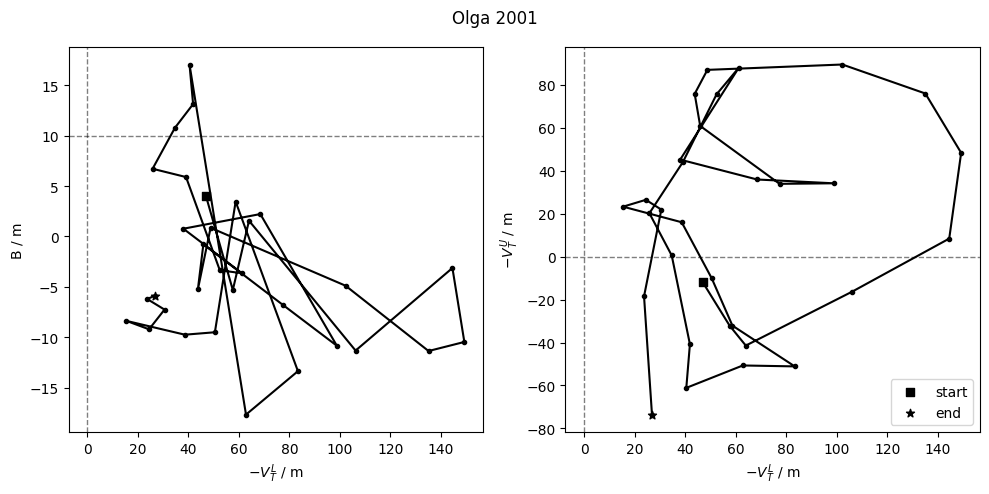

In [157]:
track = huracanpy.load("tracks/Olga_2001.csv") # Open the track data
snaps = xr.open_dataset("snaps/Olga_2001.nc").assign(level = snaps_levels) # Open the snapshots along the track
snaps["snap_geopt"] /= 9.81 # Convert geopotential to m

# Compute the Hart CPS parameters
track_w_cps = compute_cps_parameters(track, snaps.snap_geopt)
# Visualise
plot_cps(track_w_cps, "Olga 2001")

### 1982 Warm Seclusion

INFO:cpys:Computing B...
INFO:cpys:Level 90000 is taken for 900hPa
Level 60000 is taken for 600hPa

INFO:cpys:Computing VTL & VTU...


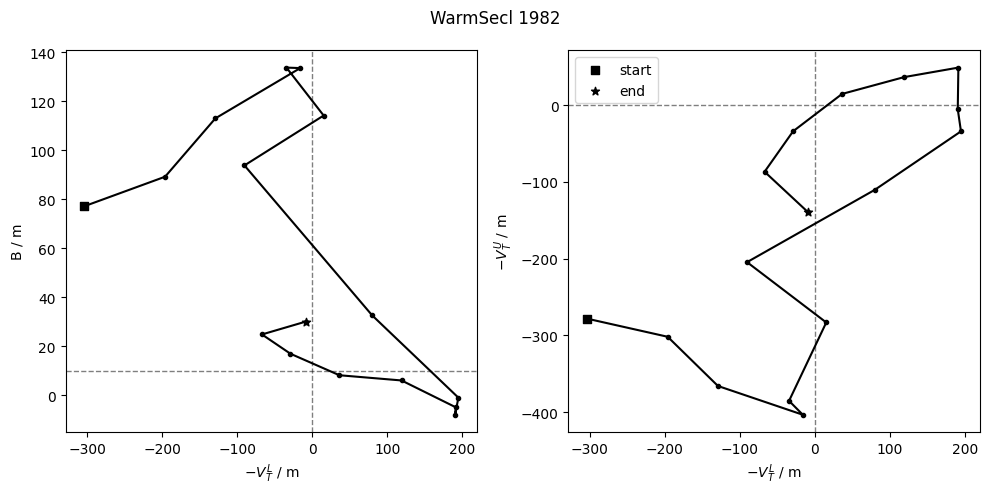

In [161]:
track = huracanpy.load("tracks/WarmSecl_1982.csv") # Open the track data
track = track.where(track.time <= np.datetime64("1982-02-17"), drop = True) # In Hart 2003, the track ends on Feb. 17th
snaps = xr.open_dataset("snaps/WarmSecl_1982.nc").assign(level = snaps_levels) # Open the snapshots along the track
snaps = snaps.where(snaps.snap_time <= np.datetime64("1982-02-17"), drop = True) # In Hart 2003, the track ends on Feb. 17th
snaps["snap_geopt"] /= 9.81 # Convert geopotential to m

# Compute the Hart CPS parameters
track_w_cps = compute_cps_parameters(track, snaps.snap_geopt)
# Visualise
plot_cps(track_w_cps, "WarmSecl 1982")